## CORNEST STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

cornerst=pd.read_csv('../stock_data/cornerst.csv') ## so it can be small letter. This is cool.
cornerst=cornerst.drop(columns=['high_price','low_price'])
cornerst.rename(columns={'trade_date':'date'},inplace=True)
cornerst['date']=pd.to_datetime(cornerst['date'])
cornerst['month']=cornerst['date'].dt.month
cornerst['quarter']=cornerst['date'].dt.quarter
cornerst['year']=cornerst['date'].dt.year

cornerst

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,81309,CORNERST,2018-09-11,0.25,0.25,411404,2026-04-08T03:07:53.572062+00:00,9,3,2018
1,81411,CORNERST,2018-09-12,0.25,0.25,91601,2026-04-08T03:07:56.190409+00:00,9,3,2018
2,81513,CORNERST,2018-09-13,0.24,0.24,156255,2026-04-08T03:07:58.529226+00:00,9,3,2018
3,81615,CORNERST,2018-09-14,0.24,0.24,35900,2026-04-08T03:08:00.944137+00:00,9,3,2018
4,81717,CORNERST,2018-09-17,0.23,0.23,206973,2026-04-08T03:08:05.572353+00:00,9,3,2018
...,...,...,...,...,...,...,...,...,...,...
1851,298045,CORNERST,2026-07-13,5.60,5.60,3952552,2026-07-13T15:10:02.995074+00:00,7,3,2026
1852,298483,CORNERST,2026-07-14,5.60,5.60,796224,2026-07-14T15:10:03.094441+00:00,7,3,2026
1853,298921,CORNERST,2026-07-15,5.60,5.60,489463,2026-07-15T15:10:03.078609+00:00,7,3,2026
1854,299359,CORNERST,2026-07-16,5.75,5.75,1570915,2026-07-16T15:10:03.113936+00:00,7,3,2026


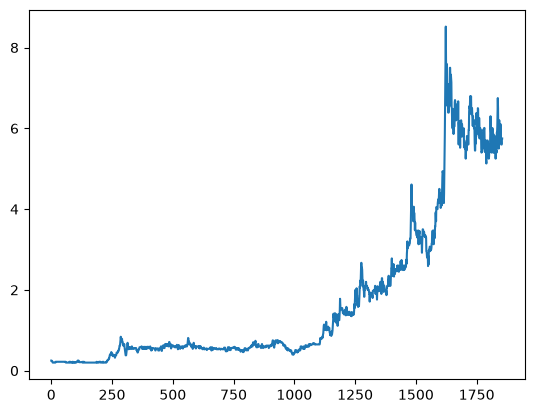

In [2]:
import matplotlib.pyplot as plt

plt.plot(cornerst['close_price'])
plt.show()

In [3]:
cornerst_end_month_df = (
    cornerst
    .sort_values("date")
    .groupby(cornerst["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

cornerst_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,82635,CORNERST,2018-09-28,0.20,0.20,200,2026-04-08T03:08:29.283021+00:00,9,3,2018
1,84777,CORNERST,2018-10-31,0.22,0.22,0,2026-04-08T03:09:32.658485+00:00,10,4,2018
2,86817,CORNERST,2018-11-30,0.22,0.22,9940,2026-04-08T03:10:32.706086+00:00,11,4,2018
3,88343,CORNERST,2018-12-31,0.20,0.20,519600,2026-04-08T03:11:26.963749+00:00,12,4,2018
4,90383,CORNERST,2019-01-31,0.22,0.22,78174,2026-04-08T03:12:45.452606+00:00,1,1,2019
...,...,...,...,...,...,...,...,...,...,...
90,35281,CORNERST,2026-03-31,5.60,5.60,1042273,2026-03-31T15:00:02.085058+00:00,3,1,2026
91,281108,CORNERST,2026-04-30,5.60,5.60,3647175,2026-04-30T15:00:02.170664+00:00,4,2,2026
92,284174,CORNERST,2026-05-29,5.45,5.45,1078487,2026-05-29T15:00:02.455558+00:00,5,2,2026
93,294103,CORNERST,2026-06-30,6.00,6.00,499207,2026-06-30T15:10:03.08168+00:00,6,2,2026


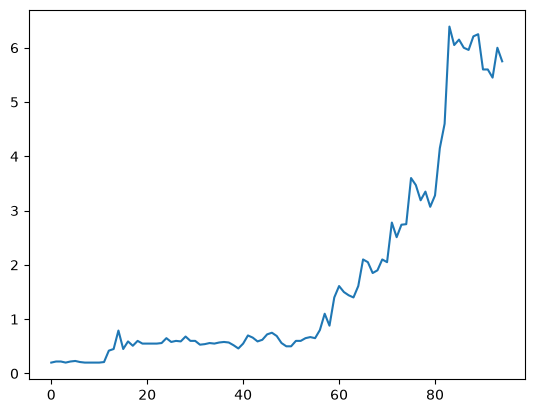

In [4]:
plt.plot(cornerst_end_month_df['close_price'])
plt.show()

In [5]:
cornerst_end_month_df['returns']=cornerst_end_month_df['close_price'].pct_change()*100
cornerst_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,82635,CORNERST,2018-09-28,0.20,0.20,200,2026-04-08T03:08:29.283021+00:00,9,3,2018,NaN
1,84777,CORNERST,2018-10-31,0.22,0.22,0,2026-04-08T03:09:32.658485+00:00,10,4,2018,10.000000
2,86817,CORNERST,2018-11-30,0.22,0.22,9940,2026-04-08T03:10:32.706086+00:00,11,4,2018,0.000000
3,88343,CORNERST,2018-12-31,0.20,0.20,519600,2026-04-08T03:11:26.963749+00:00,12,4,2018,-9.090909
4,90383,CORNERST,2019-01-31,0.22,0.22,78174,2026-04-08T03:12:45.452606+00:00,1,1,2019,10.000000
...,...,...,...,...,...,...,...,...,...,...,...
90,35281,CORNERST,2026-03-31,5.60,5.60,1042273,2026-03-31T15:00:02.085058+00:00,3,1,2026,-10.400000
91,281108,CORNERST,2026-04-30,5.60,5.60,3647175,2026-04-30T15:00:02.170664+00:00,4,2,2026,0.000000
92,284174,CORNERST,2026-05-29,5.45,5.45,1078487,2026-05-29T15:00:02.455558+00:00,5,2,2026,-2.678571
93,294103,CORNERST,2026-06-30,6.00,6.00,499207,2026-06-30T15:10:03.08168+00:00,6,2,2026,10.091743


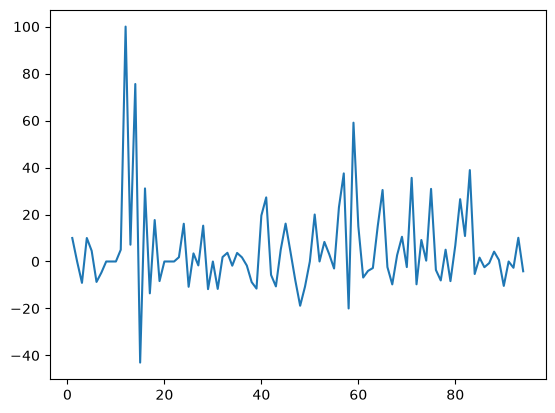

In [6]:
plt.plot(cornerst_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(cornerst_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-5.6829750968884865), np.float64(8.403294137443648e-07), 2, 91, {'1%': np.float64(-3.50434289821397), '5%': np.float64(-2.8938659630479413), '10%': np.float64(-2.5840147047458037)}, np.float64(681.9666785847301))
stationary


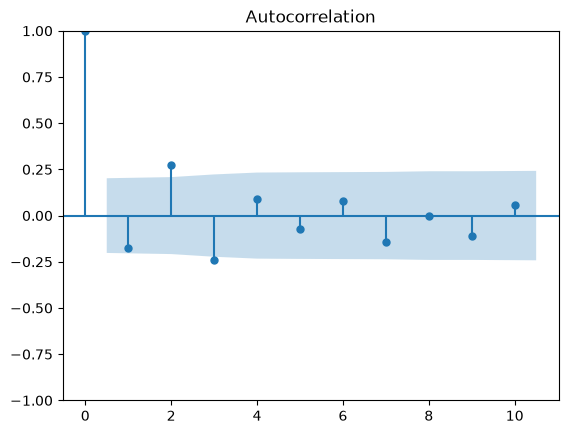

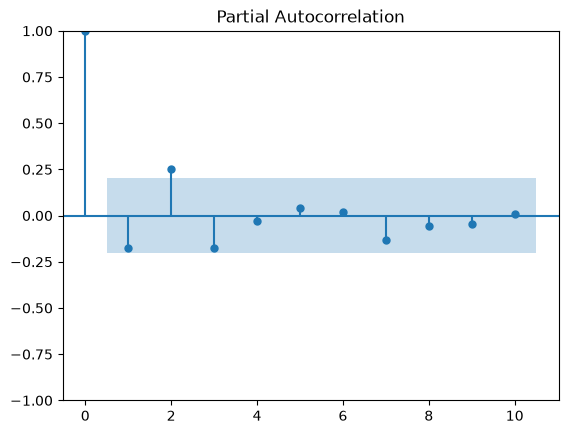

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(cornerst_end_month_df['returns'].dropna(), lags=10)
plot_pacf(cornerst_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [10]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=cornerst_end_month_df['close_price'][:-10]
test=cornerst_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -490.0524090697704]
[0, 0, 0, 0, 0, 1, -231.3073898977247]
[0, 0, 0, 0, 0, 2, -126.20277349323484]
[0, 0, 0, 0, 1, 0, -91.37285269373311]
[0, 0, 0, 0, 1, 1, -61.74979726125124]
[0, 0, 0, 0, 1, 2, -30.75041276524724]
[0, 0, 0, 0, 2, 0, -24.924240075646413]
[0, 0, 0, 0, 2, 1, -26.29763887792163]
[0, 0, 0, 0, 2, 2, -15.90112085709156]
[0, 0, 0, 1, 0, 0, -111.55948166734389]
[0, 0, 0, 1, 0, 1, -75.73897433551458]
[0, 0, 0, 1, 0, 2, -44.00401979265417]
[0, 0, 0, 1, 1, 0, -31.474027973532067]
[0, 0, 0, 1, 1, 1, -32.99791897518263]
[0, 0, 0, 1, 1, 2, -20.431307302887852]
[0, 0, 0, 1, 2, 0, -25.88810285228224]
[0, 0, 0, 1, 2, 1, -24.33021392793013]
[0, 0, 0, 1, 2, 2, -15.948532531797184]
[0, 0, 0, 2, 0, 0, -47.27940163166781]
[0, 0, 0, 2, 0, 1, -49.203159683046664]
[0, 0, 0, 2, 0, 2, -34.55196583704001]
[0, 0, 0, 2, 1, 0, -32.14468248528637]
[0, 0, 0, 2, 1, 1, -31.129606511556673]
[0, 0, 0, 2, 1, 2, -20.26614216593583]
[0, 0, 0, 2, 2, 0, -19.952058085192153]
[0, 0, 0, 2, 2, 

In [11]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-490.052409
27,0,0,1,0,0,0,-462.788232
54,0,0,2,0,0,0,-454.141297
411,1,2,0,0,2,0,-404.499460
654,2,2,0,0,2,0,-381.554626
...,...,...,...,...,...,...,...
513,2,0,1,0,0,0,-0.085500
540,2,0,2,0,0,0,0.085085
243,1,0,0,0,0,0,0.117931
270,1,0,1,0,0,0,0.137204


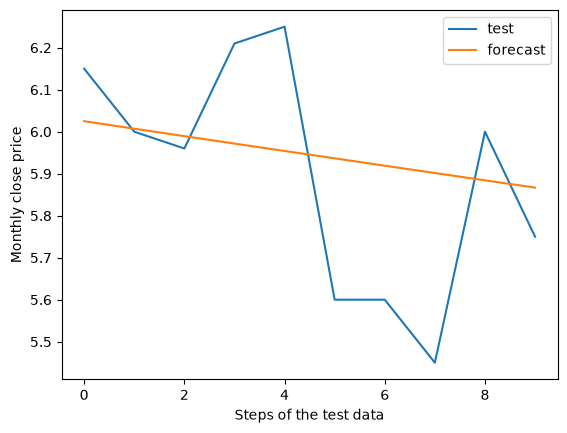

r2_score:  0.14470590179301746
rmse:  0.24635852837453331
description:  count    95.000000
mean      1.715368
std       1.892320
min       0.200000
25%       0.550000
50%       0.650000
75%       2.305000
max       6.390000
Name: close_price, dtype: float64


In [12]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=cornerst_end_month_df['close_price'][:-10]
y_test=cornerst_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,0), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', cornerst_end_month_df.close_price.describe())

Its not capturing the variations properly. Lets try the returns

In [14]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=cornerst_end_month_df['returns'].dropna()[:-10]
test=cornerst_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.00545402276464535]
[0, 0, 0, 0, 0, 1, -0.19106963233514973]
[0, 0, 0, 0, 0, 2, -0.20901156984429226]
[0, 0, 0, 0, 1, 0, -7.036719138043457]
[0, 0, 0, 0, 1, 1, -2.004578095779291]
[0, 0, 0, 0, 1, 2, -2.2703942969063253]
[0, 0, 0, 0, 2, 0, -38.94062037703944]
[0, 0, 0, 0, 2, 1, -10.404542356389877]
[0, 0, 0, 0, 2, 2, -7.592176700895996]
[0, 0, 0, 1, 0, 0, -0.33784528787248314]
[0, 0, 0, 1, 0, 1, -0.1920646653316762]
[0, 0, 0, 1, 0, 2, -0.618722755281176]
[0, 0, 0, 1, 1, 0, -1.8197855655486017]
[0, 0, 0, 1, 1, 1, -1.861054029076012]
[0, 0, 0, 1, 1, 2, -1.7464777437232981]
[0, 0, 0, 1, 2, 0, -7.211190485383055]
[0, 0, 0, 1, 2, 1, -4.898375323056171]
[0, 0, 0, 1, 2, 2, -4.230818367498621]
[0, 0, 0, 2, 0, 0, -0.037464334109547526]
[0, 0, 0, 2, 0, 1, -0.2853903900203909]
[0, 0, 0, 2, 0, 2, -0.4759937477751983]
[0, 0, 0, 2, 1, 0, -1.8352186920325382]
[0, 0, 0, 2, 1, 1, -1.83117319354014]
[0, 0, 0, 2, 1, 2, -1.584572481117426]
[0, 0, 0, 2, 2, 0, -4.9996116156191075]
[0, 0,

In [15]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
182,0,2,0,2,0,2,-4499.638755
162,0,2,0,0,0,0,-2988.140454
179,0,2,0,1,2,2,-2520.229161
170,0,2,0,0,2,2,-2228.524719
173,0,2,0,1,0,2,-1984.766165
...,...,...,...,...,...,...,...
27,0,0,1,0,0,0,-0.003349
72,0,0,2,2,0,0,0.000703
243,1,0,0,0,0,0,0.000712
288,1,0,1,2,0,0,0.040526


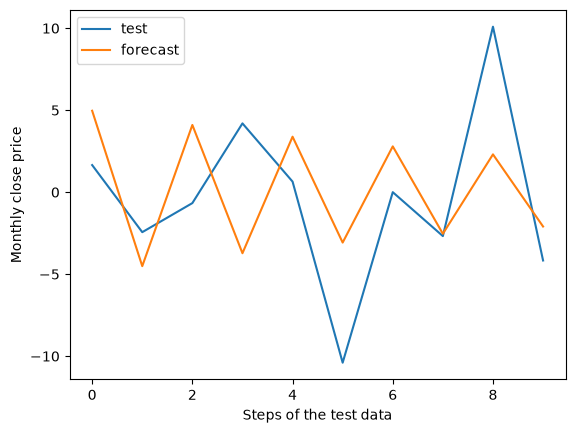

r2_score:  0.09857256998327713
rmse:  4.843561385770869
description:  count     94.000000
mean       5.092826
std       19.015562
min      -43.037975
25%       -4.613095
50%        0.000000
75%       10.000000
max      100.000000
Name: returns, dtype: float64


In [17]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=cornerst_end_month_df['returns'].dropna()[:-10]
y_test=cornerst_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,0,1), 
seasonal_order=(0,0,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', cornerst_end_month_df.returns.dropna().describe())

Not good enough. But we will work with it
